# Estudio completo de minería de datos aplicado a oncología

## Sistema Web de Recomendación de Tratamientos Personalizados en Oncología

**Entrega académica reproducible en Python**  
Autor: Enrique Catrilaf González  
Curso: Máster en Inteligencia Artificial Aplicada

> Advertencia: este estudio clasifica una etiqueta histórica de un dataset académico. No prescribe, no recomienda tratamientos y no demuestra eficacia clínica.

La organización reproduce el enfoque de los estudios docentes Ames Housing y Super Telco Churn: CRISP-DM, auditoría de calidad, prevención de leakage, split congelado, validación cruzada, torneo de modelos, análisis de errores, segmentación y limitaciones.

## 0. Reproducibilidad

El notebook invoca el mismo pipeline que `python run_all.py`. La ejecución comienza verificando el SHA-256 del CSV original de Kaggle v1 y reconstruyendo los datasets derivados. Todas las transformaciones del modelo se aprenden dentro de cada fold mediante `Pipeline` y `ColumnTransformer`. La semilla global es 42.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / "run_all.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import run_analysis

summary = run_analysis(ROOT)
summary

{'dataset_rows_clean': 52321,
 'dataset_rows_model_ready': 49765,
 'selected_model': 'Random Forest',
 'cv_f1_macro_mean': 0.2520542043967347,
 'cv_balanced_accuracy_mean': 0.25254761558516137,
 'holdout_f1_macro': 0.2495975280189324,
 'holdout_balanced_accuracy': 0.24990926957289963,
 'holdout_f1_macro_ci95': [0.24201436753615654, 0.2567767169169439],
 'holdout_balanced_accuracy_ci95': [0.24223630817387573, 0.2571296644976978],
 'paired_cv_delta_f1_vs_dummy': -0.0004447611194079437,
 'paired_cv_delta_f1_ci95': [-0.006389413812727706, 0.0049709967798533036],
 'ece_top_label': 0.026528908974013735,
 'label_randomization_p_value': 0.4991001799640072,
 'label_randomization_null_f1_mean': 0.24960905767630653,
 'brier_skill_vs_prevalence': -0.011800282443850119,
 'log_loss_gain_vs_prevalence': -0.01699444366270897,
 'learning_curve_final_validation_f1': 0.24997503514238148,
 'dummy_stratified_cv_f1_macro': 0.2524989655161426,
 'delta_f1_vs_dummy': -0.0004447611194078882,
 'abstention_rate_h

## 1. Comprensión del problema (CRISP-DM)

La pregunta computacional es: **¿pueden las variables pretratamiento predecir el régimen de quimioterapia registrado?**

La pregunta clínica "¿cuál es el mejor tratamiento?" es diferente y no puede contestarse con estos datos. Requeriría indicación clínica, comparadores, temporalidad, confusores, guías, outcomes acreditados y validación prospectiva.

## 2. Comprensión y calidad de los datos

In [2]:
quality = pd.read_csv(ROOT / "outputs/tables/01_resumen_calidad.csv")
consistency = pd.read_csv(ROOT / "outputs/tables/05_consistencia_clinica.csv")
integrity = pd.read_csv(ROOT / "outputs/tables/30_integridad_perfiles_predictores.csv")
numeric_associations = pd.read_csv(ROOT / "outputs/tables/31_asociaciones_numericas_target.csv")
display(quality)
display(consistency)
display(integrity)
display(numeric_associations.round(6))

,indicador,valor
0,Registros del dataset limpio,52321
1,Columnas del dataset limpio,31
2,Registros con régimen conocido,49765
3,Columnas del dataset model-ready,29
4,Registros sin régimen en el dataset limpio,2556
5,Valores faltantes en model-ready,0
6,Patient ID duplicados,0
7,Filas completamente duplicadas,0
8,Clases de régimen,4


,control,n_registros,pct_registros,interpretacion
0,Estadio IV sin metástasis registrada,5220,0.104893,Revisar semántica y procedencia; no corregir a...
1,Estadio I con metástasis registrada,3699,0.074329,Combinación clínicamente atípica; requiere val...
2,Respuesta favorable y progresión simultáneas,0,0.000000,Debe ser cero por definición de variables deri...


,indicador,valor,interpretacion
0,Registros evaluados,49765,Unidad de análisis del model-ready
1,Identificadores únicos,49765,Debe coincidir con los registros
2,Perfiles predictores únicos,49763,Combinaciones exactas de las nueve entradas
3,Filas pertenecientes a perfiles repetidos,4,Incluye todas las copias
4,Perfiles repetidos,2,Combinaciones exactas presentes más de una vez
5,Perfiles repetidos con etiquetas en conflicto,0,Un valor mayor que cero indicaría ambigüedad d...
6,Máximo de registros por perfil,2,Concentración máxima de una combinación exacta


,variable,eta_cuadrado,p_value_kruskal,interpretacion,p_value_fdr_bh,significativo_fdr_005
0,bmi,0.000093,0.199764,Efecto despreciable,0.344900,False
1,tumor_size_cm,0.000087,0.229933,Efecto despreciable,0.344900,False
2,age,0.000006,0.961997,Efecto despreciable,0.961997,False


Los controles cruzados se reportan, pero no se corrigen automáticamente. El archivo y su licencia están verificados contra Kaggle v1, pero la procedencia clínica no está acreditada; por ello no es posible distinguir con seguridad entre errores, definiciones no documentadas y un mecanismo de generación desconocido.

### 2.1. Distribución del target y EDA

,chemotherapy_regimen,n,proporcion
0,FOLFOX,15699,0.315463
1,ABVD,13052,0.262273
2,CHOP,10639,0.213785
3,Gemcitabine,10375,0.208480


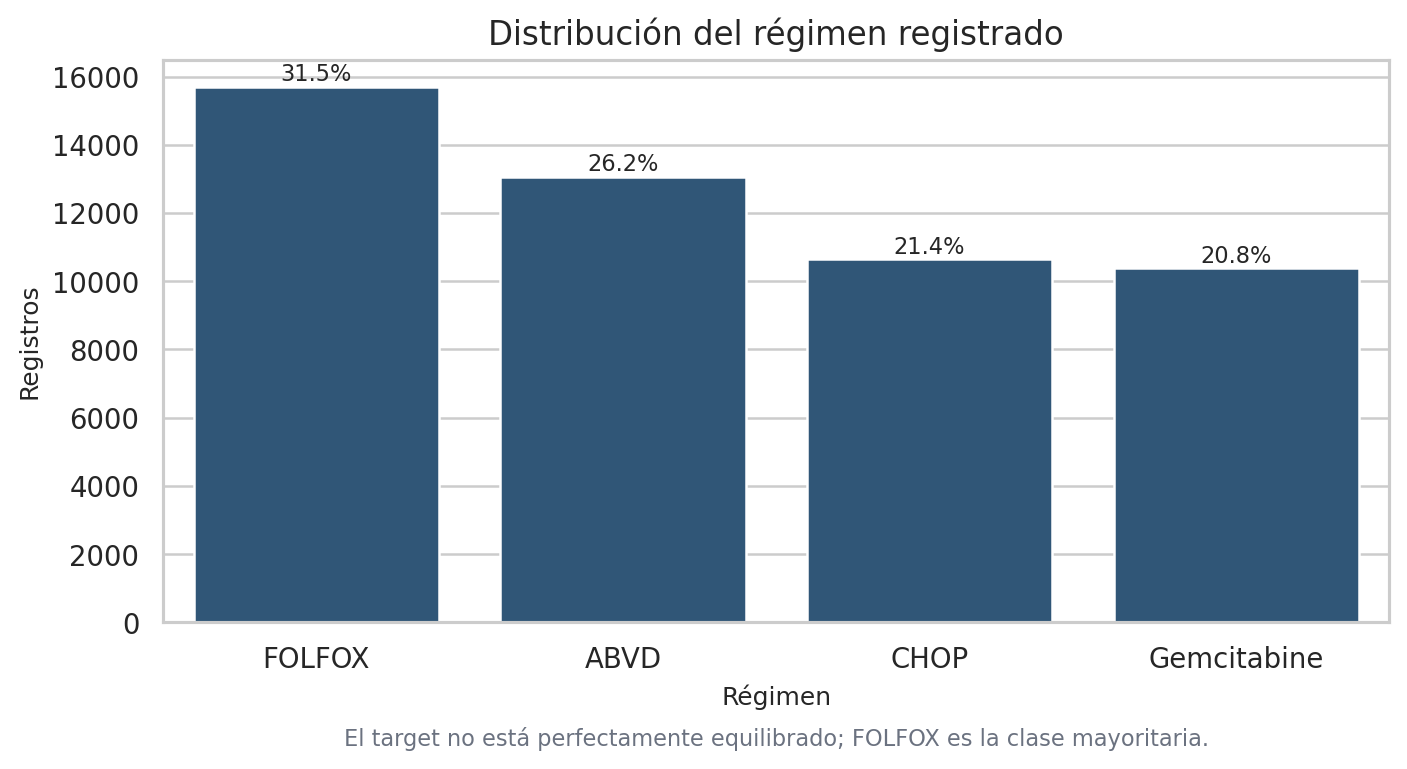

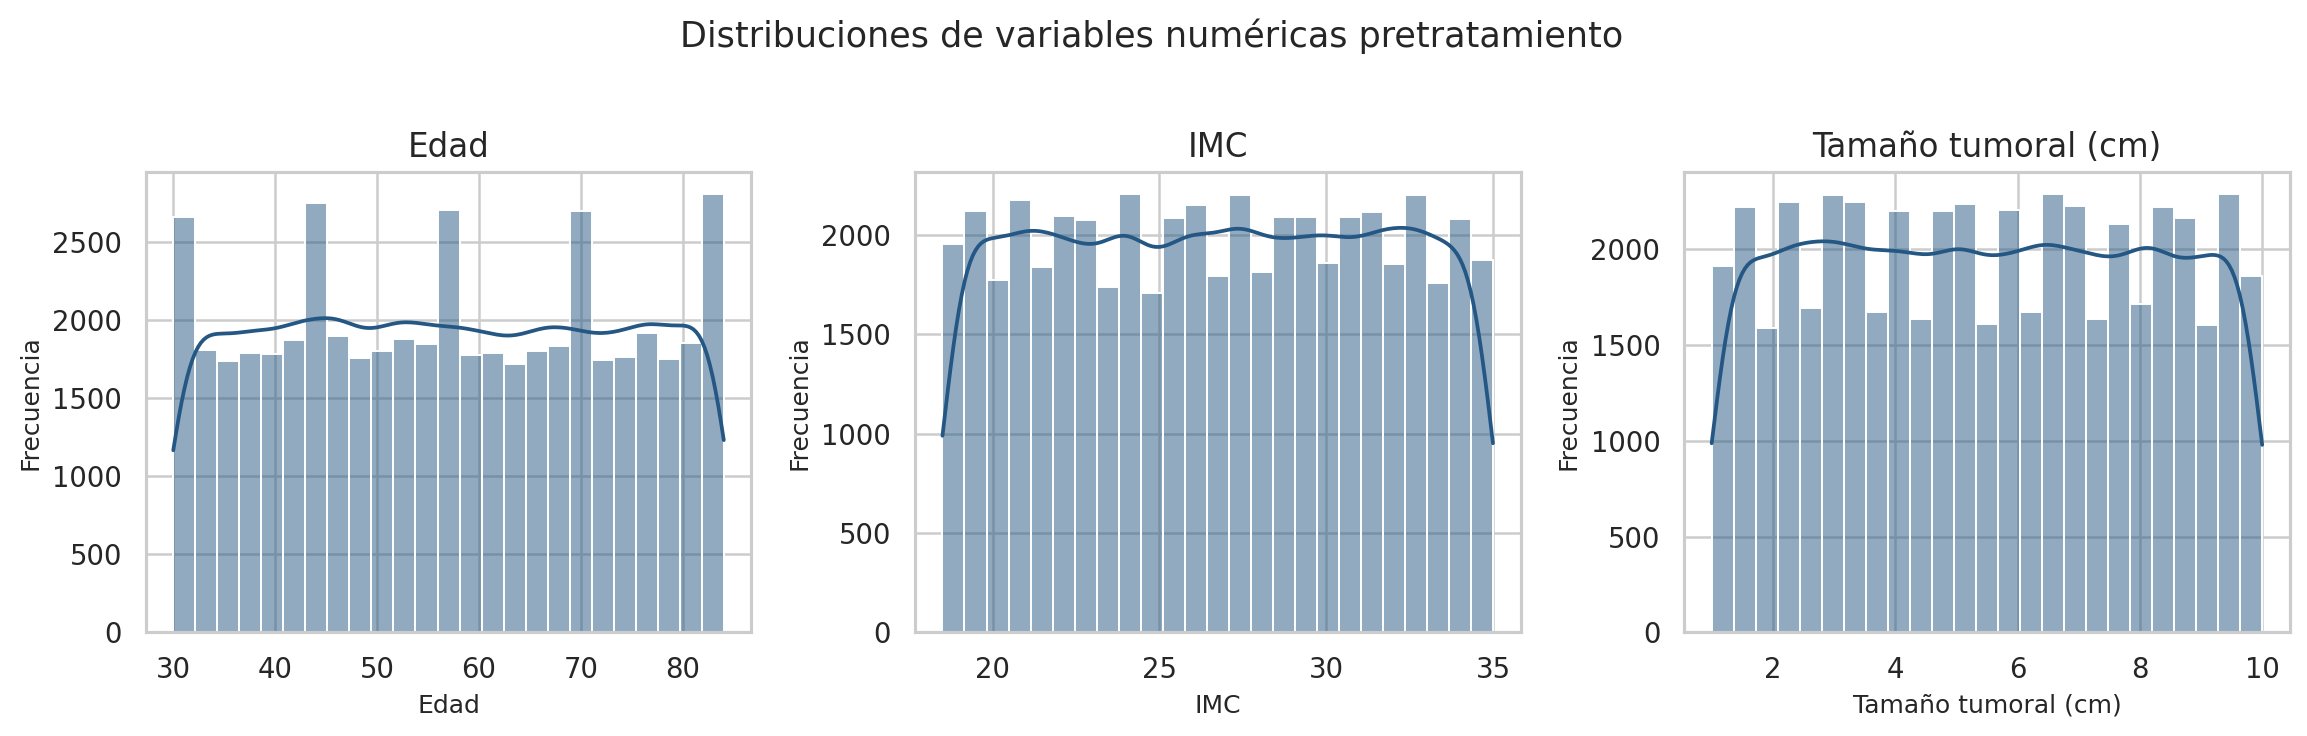

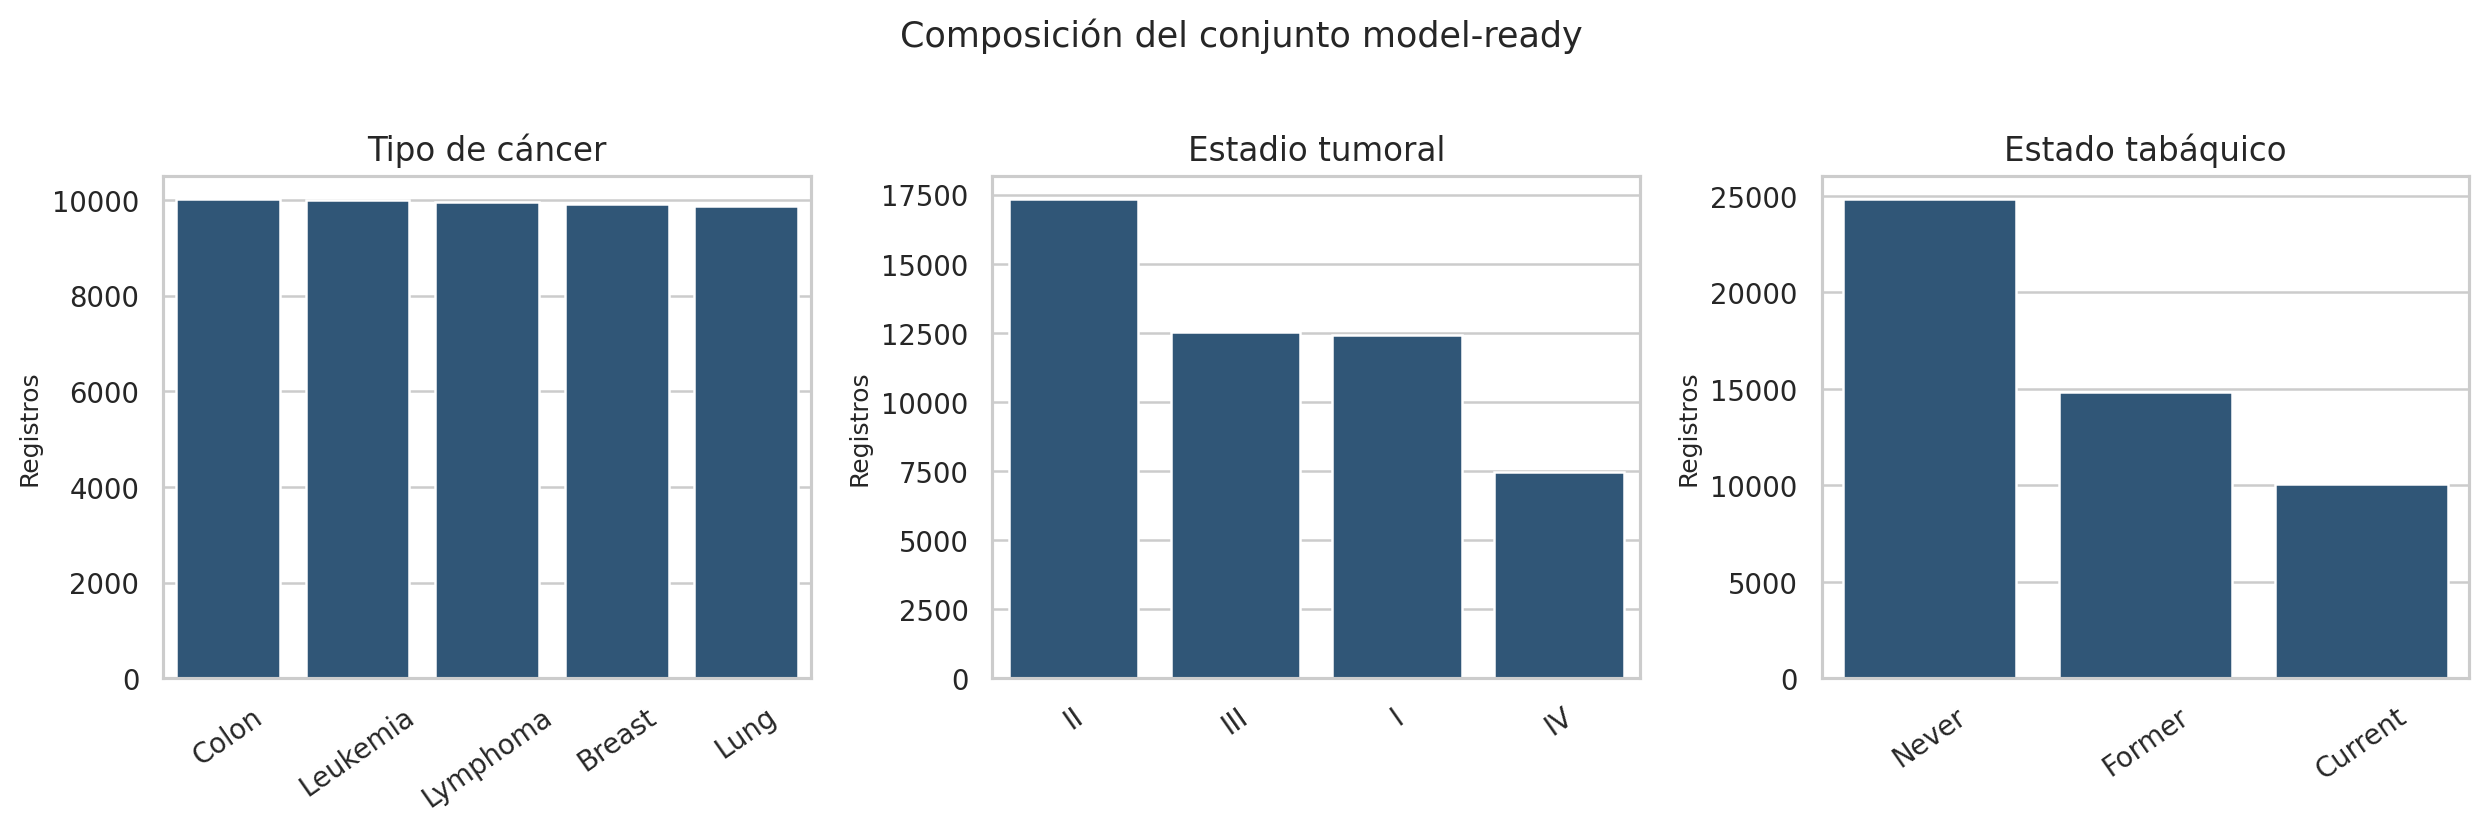

In [3]:
display(pd.read_csv(ROOT / "outputs/tables/07_distribucion_target.csv"))
display(Image(filename=str(ROOT / "outputs/figures/01_distribucion_target.png"), width=760))
display(Image(filename=str(ROOT / "outputs/figures/02_eda_numericas.png"), width=980))
display(Image(filename=str(ROOT / "outputs/figures/03_eda_categoricas.png"), width=980))

### 2.2. ¿Existe asociación entre contexto clínico y régimen?

,variable,cramers_v_corregido,p_value_chi2,interpretacion,p_value_fdr_bh,significativo_fdr_005
0,clinical_risk_group,0.007116,0.087136,Asociación despreciable,0.590382,False
1,smoking_status,0.003889,0.276639,Asociación despreciable,0.590382,False
2,genetic_mutation,0.002482,0.374881,Asociación despreciable,0.590382,False
3,cancer_type,0.002401,0.379242,Asociación despreciable,0.590382,False
4,sex,0.000000,0.531344,Asociación despreciable,0.590382,False
5,tumor_stage,0.000000,0.465449,Asociación despreciable,0.590382,False
6,metastasis_status,0.000000,0.502008,Asociación despreciable,0.590382,False
7,age_group,0.000000,0.847790,Asociación despreciable,0.847790,False
8,bmi_category,0.000000,0.435380,Asociación despreciable,0.590382,False
9,frailty_risk_pre,0.000000,0.456970,Asociación despreciable,0.590382,False


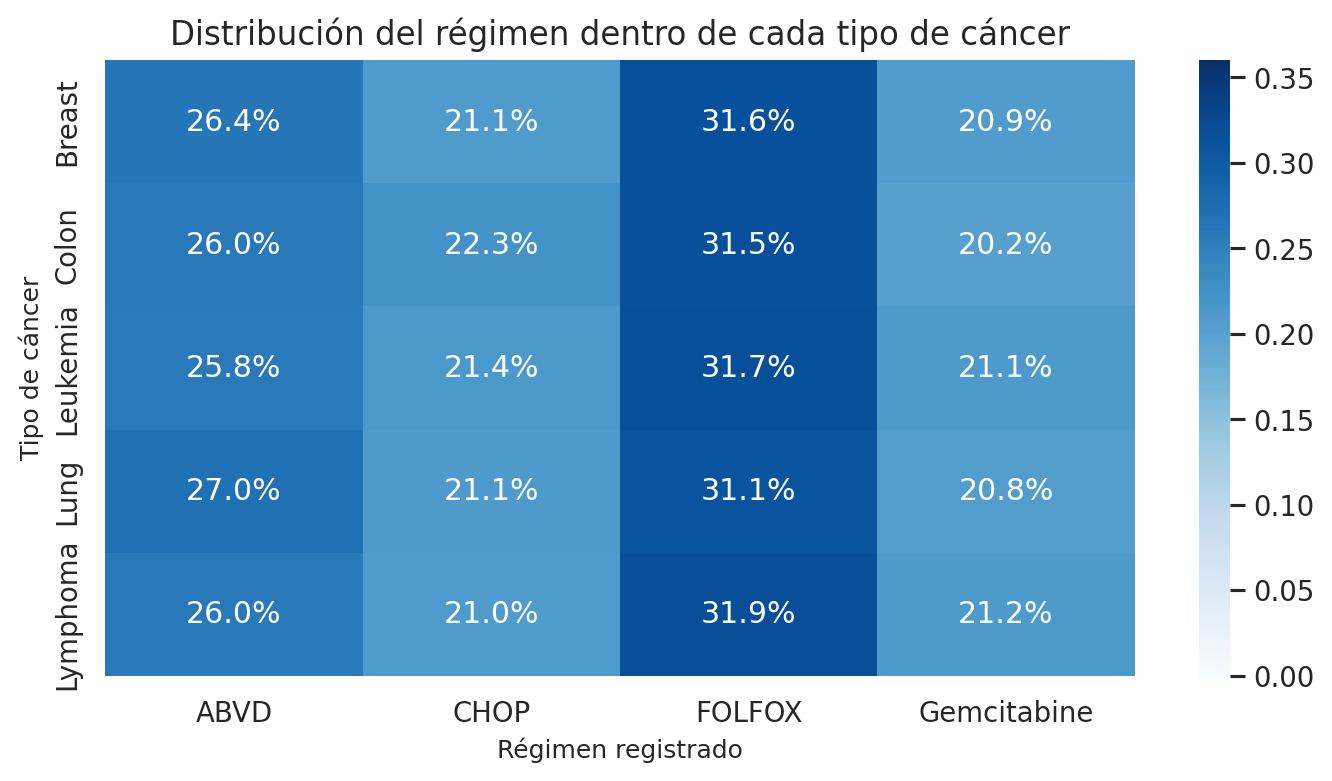

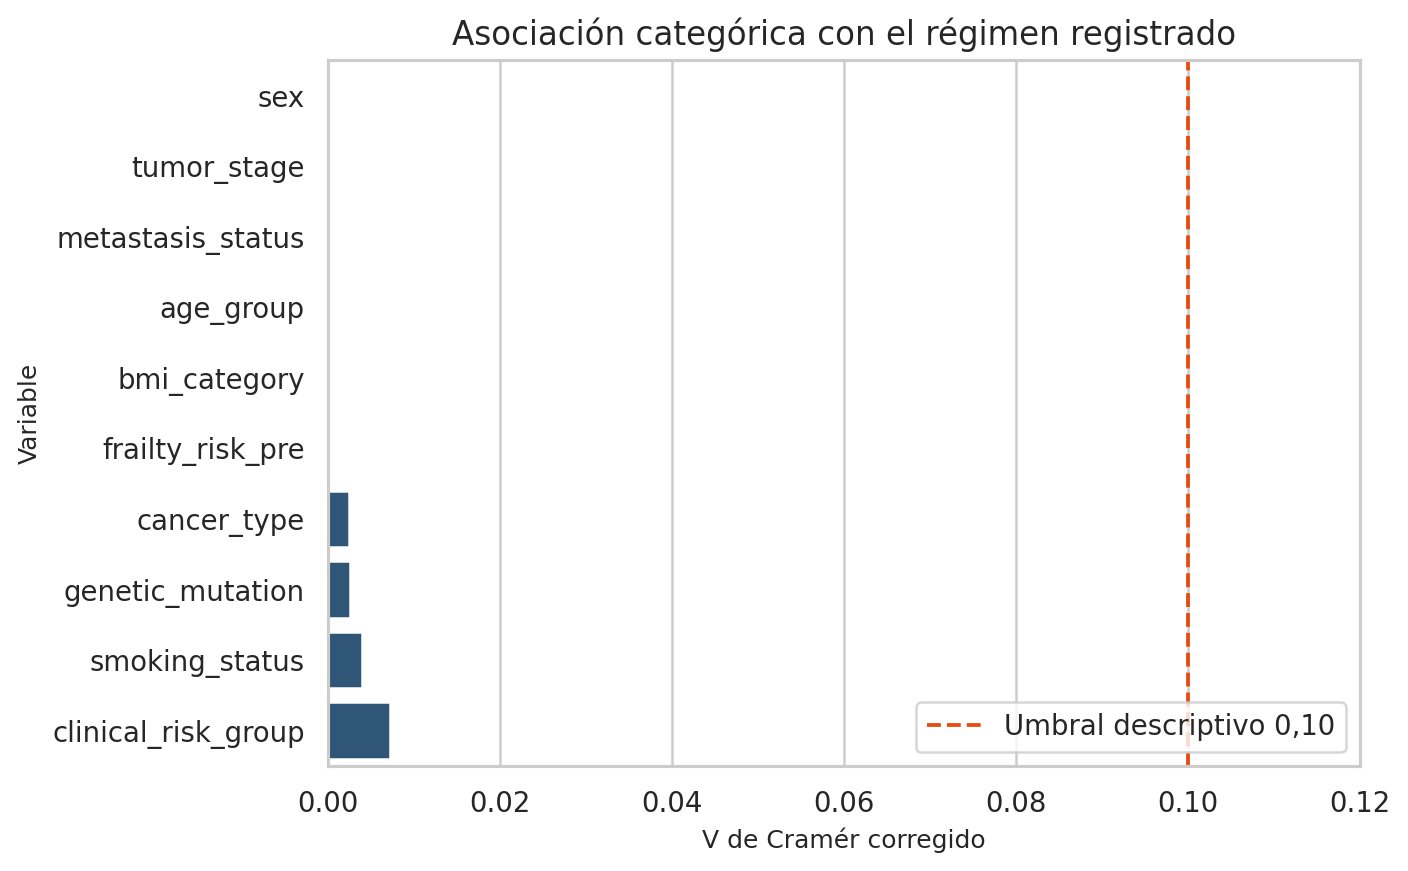

In [4]:
associations = pd.read_csv(ROOT / "outputs/tables/08_asociaciones_cramers_v.csv")
display(associations)
display(Image(filename=str(ROOT / "outputs/figures/04_regimen_por_cancer.png"), width=760))
display(Image(filename=str(ROOT / "outputs/figures/05_asociaciones_target.png"), width=760))

Los valores de V de Cramér corregido son prácticamente cero. Esta es una señal de alerta previa al modelado: el target parece casi independiente de variables que deberían ser clínicamente relevantes, como tipo de cáncer, estadio o mutación.

## 3. Preparación y auditoría de leakage

In [5]:
leakage = pd.read_csv(ROOT / "outputs/tables/06_auditoria_leakage.csv")
display(leakage)

,variable,rol_temporal,decision
0,patient_id,Identificador,Excluir del modelado
1,age,Pretratamiento,Incluir en el modelo principal
2,age_group,Derivada de pretratamiento,Excluir del modelo principal por redundancia
3,sex,Pretratamiento,Incluir en el modelo principal
4,bmi,Pretratamiento,Incluir en el modelo principal
5,bmi_category,Derivada de pretratamiento,Excluir del modelo principal por redundancia
6,smoking_status,Pretratamiento,Incluir en el modelo principal
7,cancer_type,Pretratamiento,Incluir en el modelo principal
8,genetic_mutation,Pretratamiento,Incluir en el modelo principal
9,tumor_stage,Pretratamiento,Incluir en el modelo principal


Solo se utilizan variables conocidas antes de la elección terapéutica. Dosis, ciclos, toxicidad, respuesta y supervivencia se excluyen porque contienen información posterior. Las variables derivadas redundantes también se excluyen para mantener parsimonia.

## 4. Diseño experimental

In [6]:
split_manifest = pd.read_csv(ROOT / "outputs/tables/10_manifest_split.csv")
display(split_manifest)

,subconjunto,n,proporcion,semilla
0,train,37323,0.749985,42
1,holdout_test,12442,0.250015,42


Se reserva un holdout estratificado del 25 %. Dentro del 75 % de entrenamiento se ejecuta una validación cruzada estratificada de 5 folds y 2 repeticiones. El holdout no participa en la elección del modelo.

## 5. Torneo de modelos

,modelo,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,log_loss_mean,log_loss_std
0,Dummy estratificado,0.2614,0.0061,0.2526,0.0059,0.2525,0.0060,0.2526,0.0059,0.2525,0.0060,26.6221,0.2184
1,Random Forest,0.2563,0.0052,0.2525,0.0051,0.2523,0.0051,0.2525,0.0051,0.2521,0.0051,1.3881,0.0007
2,Extra Trees,0.2534,0.0044,0.2514,0.0042,0.2510,0.0042,0.2514,0.0042,0.2504,0.0042,1.4118,0.0023
3,Regresión logística,0.2468,0.0030,0.2488,0.0037,0.2495,0.0041,0.2488,0.0037,0.2452,0.0030,1.3874,0.0004
4,Árbol CART,0.2383,0.0069,0.2495,0.0036,0.2479,0.0053,0.2495,0.0036,0.2287,0.0118,1.3971,0.0029
5,Dummy mayoría,0.3155,0.0000,0.2500,0.0000,0.0789,0.0000,0.2500,0.0000,0.1199,0.0000,24.6732,0.0017


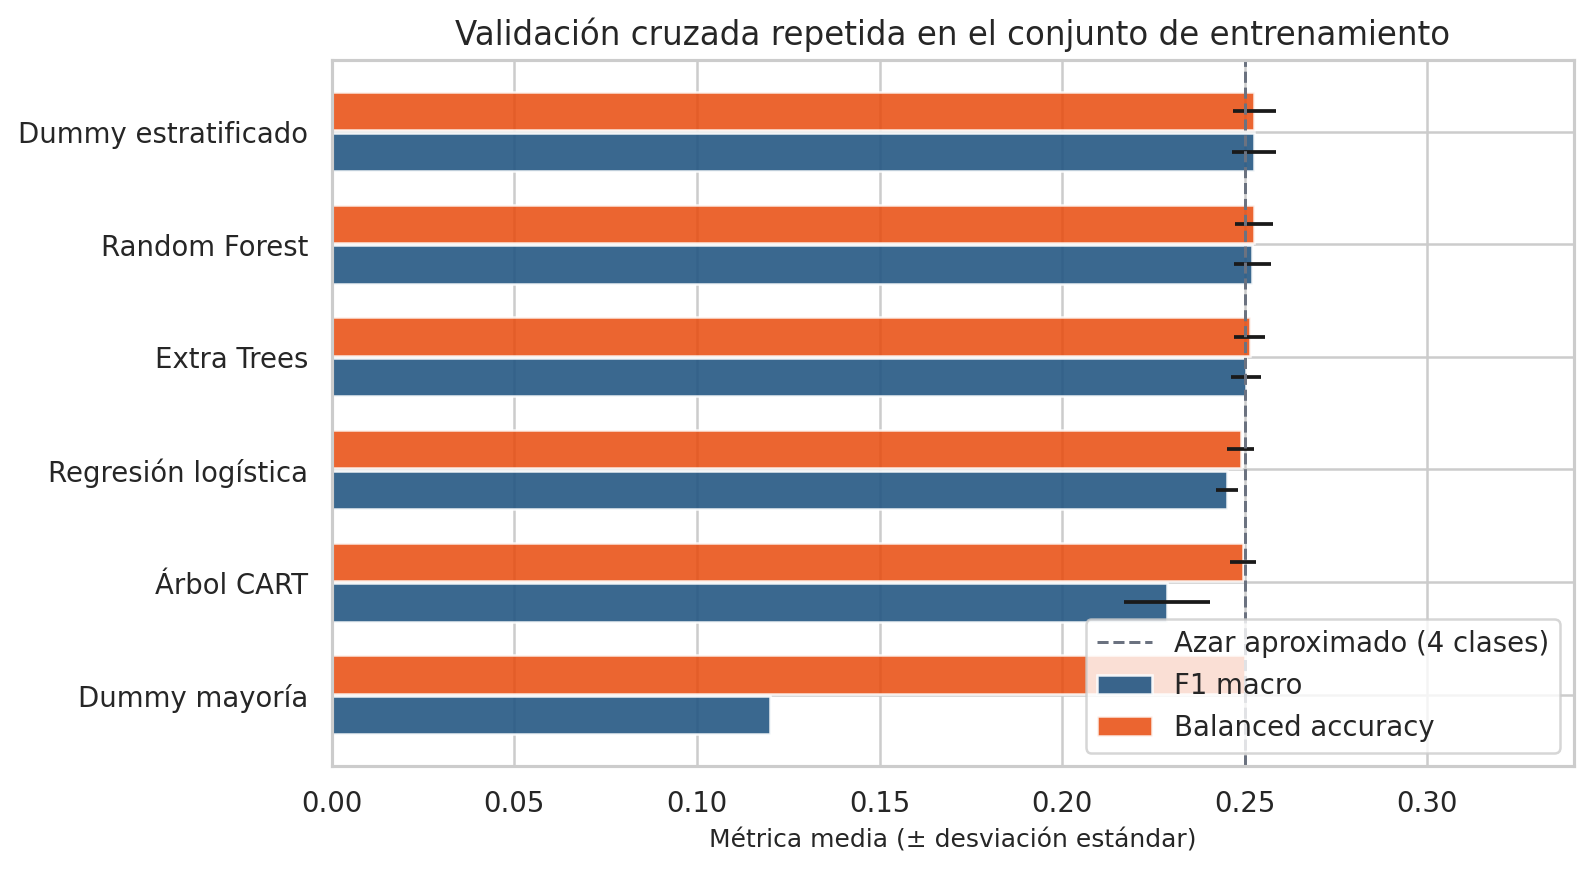

In [7]:
cv = pd.read_csv(ROOT / "outputs/tables/12_cv_resumen_modelos.csv")
display(cv.round(4))
display(Image(filename=str(ROOT / "outputs/figures/06_comparacion_cv.png"), width=820))

El modelo experimental se selecciona por F1 macro medio entre los modelos no Dummy. El resultado debe compararse siempre con el Dummy estratificado. Una diferencia de unas milésimas, dentro de la variabilidad entre folds, no constituye una mejora material.

## 6. Evaluación final en holdout

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,log_loss,brier_multiclase,top2_accuracy,confianza_media
0,Random Forest,0.2544,0.2499,0.2500,0.2499,0.2496,0.2557,0.0003,1.3887,0.7513,0.5106,0.2809
1,Dummy estratificado,0.2570,0.2493,0.2493,0.2493,0.2493,0.2568,-0.0012,26.7793,1.4859,0.4877,1.0000
2,Regresión logística,0.2503,0.2522,0.2524,0.2522,0.2491,0.2516,0.0033,1.3865,0.7501,0.5047,0.2604
3,Extra Trees,0.2525,0.2496,0.2499,0.2496,0.2489,0.2543,0.0001,1.4092,0.7614,0.5036,0.3212
4,Árbol CART,0.2438,0.2469,0.2481,0.2469,0.2365,0.2399,-0.0038,1.3955,0.7546,0.4883,0.2813
5,Dummy mayoría,0.3155,0.2500,0.0789,0.2500,0.1199,0.1513,0.0000,24.6732,1.3691,0.5240,1.0000


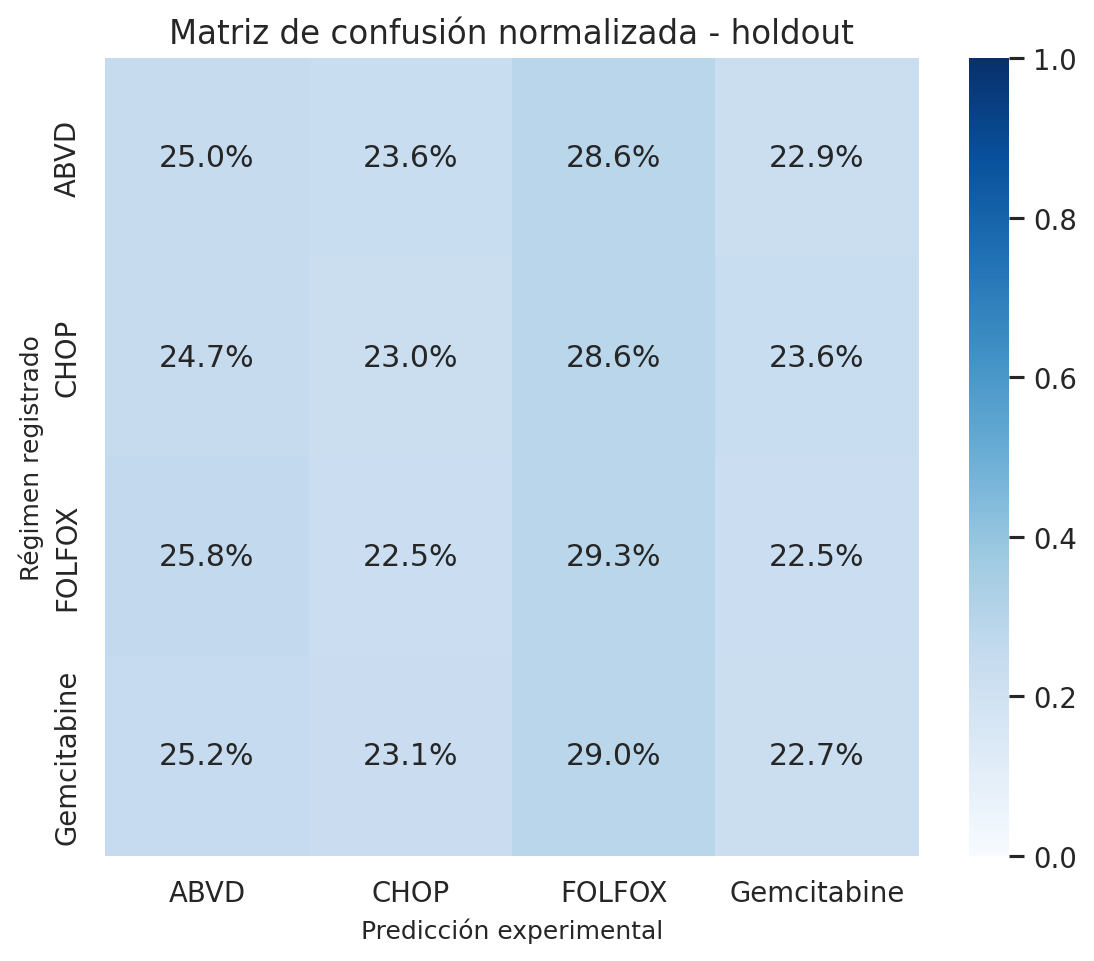

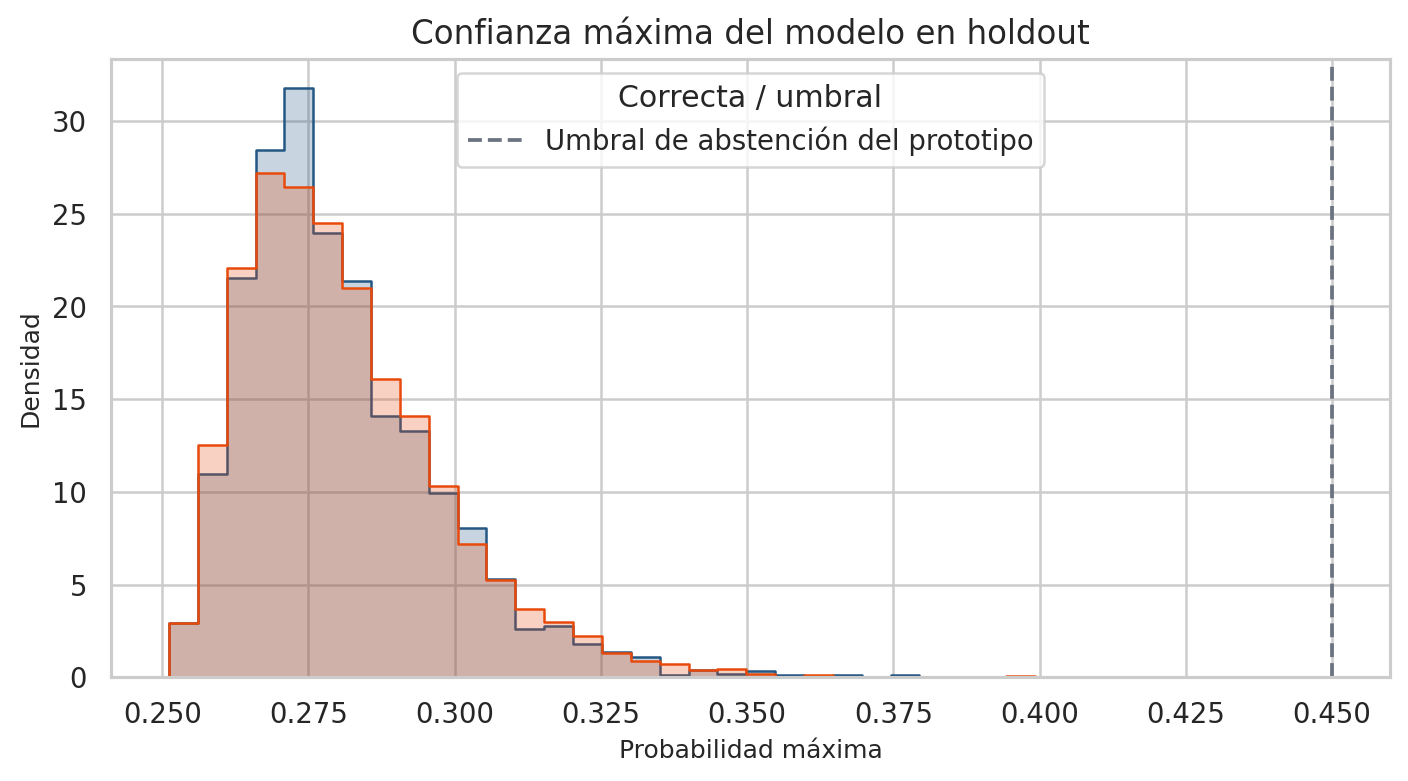

In [8]:
holdout = pd.read_csv(ROOT / "outputs/tables/13_metricas_holdout_modelos.csv")
display(holdout.round(4))
display(Image(filename=str(ROOT / "outputs/figures/07_matriz_confusion.png"), width=620))
display(Image(filename=str(ROOT / "outputs/figures/08_confianza_holdout.png"), width=760))

Balanced accuracy y F1 macro próximas a 0,25 son consistentes con azar en cuatro clases. La confianza máxima también es baja; por eso la interfaz aplica abstención en lugar de convertir una probabilidad débil en una recomendación.

### 6.1. Robustez, calibración y comparación pareada

,metrica,estimacion,ic95_inferior,ic95_superior,n_bootstrap
0,balanced_accuracy,0.2499,0.2422,0.2571,500
1,f1_macro,0.2496,0.2420,0.2568,500
2,mcc,0.0003,-0.0092,0.0096,500
3,log_loss,1.3887,1.3872,1.3906,500
4,brier_multiclase,0.7513,0.7505,0.7522,500
5,top2_accuracy,0.5106,0.5004,0.5187,500


,modelo_seleccionado,comparador,n_pares,delta_f1_macro_medio,delta_f1_ic95_inferior,delta_f1_ic95_superior,delta_balanced_accuracy_medio,delta_balanced_accuracy_ic95_inferior,delta_balanced_accuracy_ic95_superior,p_wilcoxon_f1,lectura
0,Random Forest,Dummy mayoría,10,0.1321,0.1291,0.1352,0.0025,-0.0005,0.0056,0.0020,Diferencia consistente en los folds
1,Random Forest,Árbol CART,10,0.0233,0.0160,0.0316,0.0030,-0.0007,0.0067,0.0020,Diferencia consistente en los folds
2,Random Forest,Regresión logística,10,0.0068,0.0030,0.0109,0.0037,-0.0003,0.0082,0.0098,Diferencia consistente en los folds
3,Random Forest,Extra Trees,10,0.0017,-0.0020,0.0051,0.0012,-0.0026,0.0046,0.4922,Sin evidencia de diferencia
4,Random Forest,Dummy estratificado,10,-0.0004,-0.0064,0.0050,-0.0000,-0.0058,0.0053,0.9219,Sin evidencia de diferencia


,bin,limite_inferior,limite_superior,n,confianza_media,accuracy_observada,brecha_calibracion,peso
0,3,0.2,0.3,10849,0.2761,0.2557,-0.0204,0.872
1,4,0.3,0.4,1593,0.3137,0.2454,-0.0683,0.128


,umbral,n_no_abstenciones,cobertura,tasa_abstencion,accuracy_selectiva,balanced_accuracy_selectiva,f1_macro_selectivo
0,0.25,12442,1.0000,0.0000,0.2544,0.2499,0.2496
1,0.27,8803,0.7075,0.2925,0.2558,0.2512,0.2509
2,0.28,5501,0.4421,0.5579,0.2449,0.2408,0.2404
3,0.30,1593,0.1280,0.8720,0.2454,0.2427,0.2420
4,0.32,381,0.0306,0.9694,0.2362,0.2340,0.2330
5,0.35,30,0.0024,0.9976,0.3667,0.3661,0.3644
6,0.40,0,0.0000,1.0000,NaN,NaN,NaN
7,0.45,0,0.0000,1.0000,NaN,NaN,NaN
8,0.50,0,0.0000,1.0000,NaN,NaN,NaN


,f1_macro_observado,f1_macro_nulo_medio,f1_macro_nulo_ic95_inferior,f1_macro_nulo_ic95_superior,p_unilateral_superior,n_permutaciones,conclusion
0,0.2496,0.2496,0.2422,0.2573,0.4991,5000,Sin evidencia de concordancia superior al azar


,modelo,fraccion_train,n_entrenamiento_por_fold,f1_train_media,f1_train_std,f1_validacion_media,f1_validacion_std,n_folds
0,Random Forest,0.10,2488,0.8642,0.0063,0.2492,0.0039,3
1,Random Forest,0.25,6220,0.8432,0.0110,0.2498,0.0024,3
2,Random Forest,0.50,12441,0.8039,0.0101,0.2528,0.0028,3
3,Random Forest,0.75,18661,0.7708,0.0092,0.2524,0.0043,3
4,Random Forest,1.00,24882,0.7496,0.0124,0.2500,0.0033,3
5,Dummy estratificado,0.10,2488,0.2518,0.0013,0.2506,0.0032,3
6,Dummy estratificado,0.25,6220,0.2468,0.0041,0.2501,0.0062,3
7,Dummy estratificado,0.50,12441,0.2486,0.0057,0.2517,0.0050,3
8,Dummy estratificado,0.75,18661,0.2484,0.0021,0.2499,0.0035,3
9,Dummy estratificado,1.00,24882,0.2443,0.0022,0.2501,0.0029,3


,modelo,brier_multiclase,brier_skill_vs_prevalencia,log_loss,ganancia_log_loss_vs_prevalencia
0,Random Forest,0.7513,-0.0118,1.3887,-0.0170
1,Baseline prevalencia train,0.7425,0.0000,1.3717,0.0000
2,Baseline uniforme,0.7500,-0.0101,1.3863,-0.0146


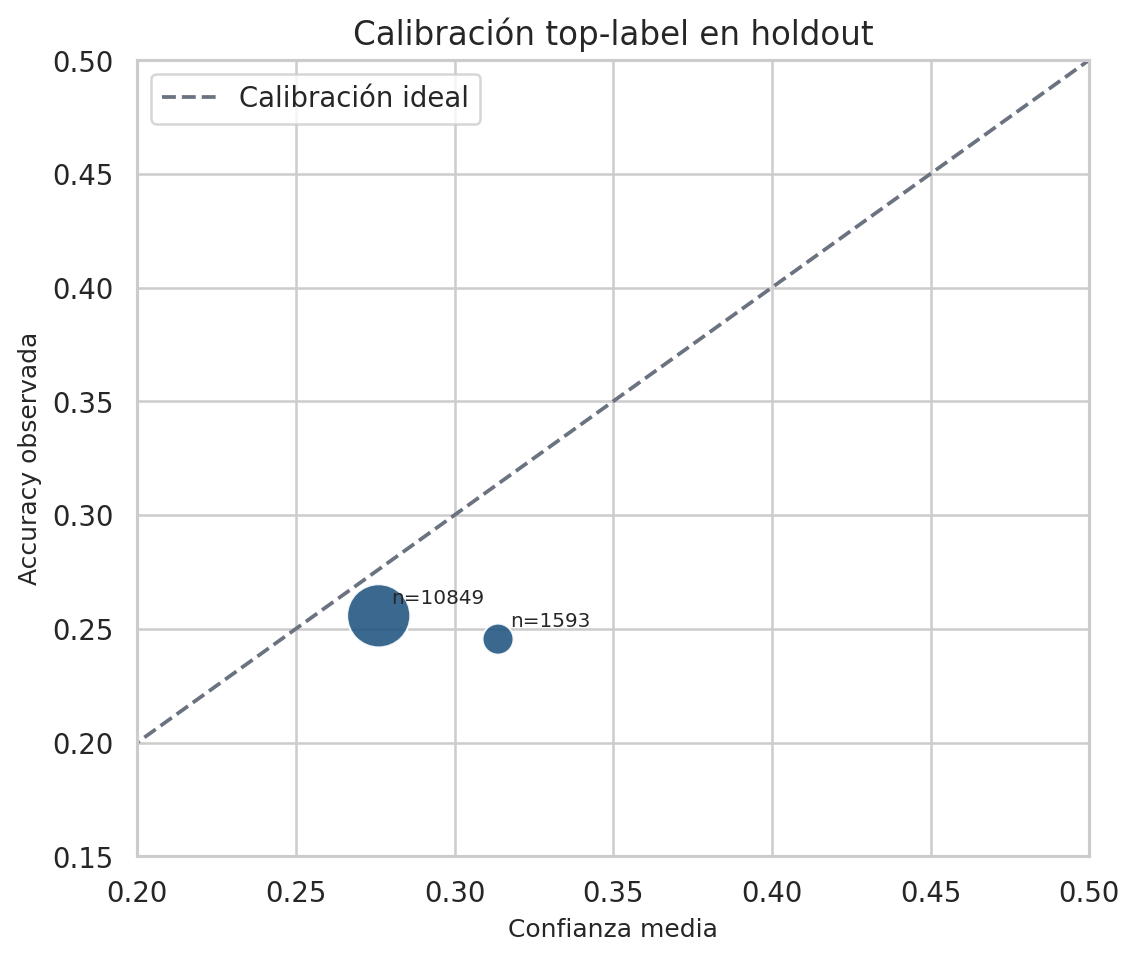

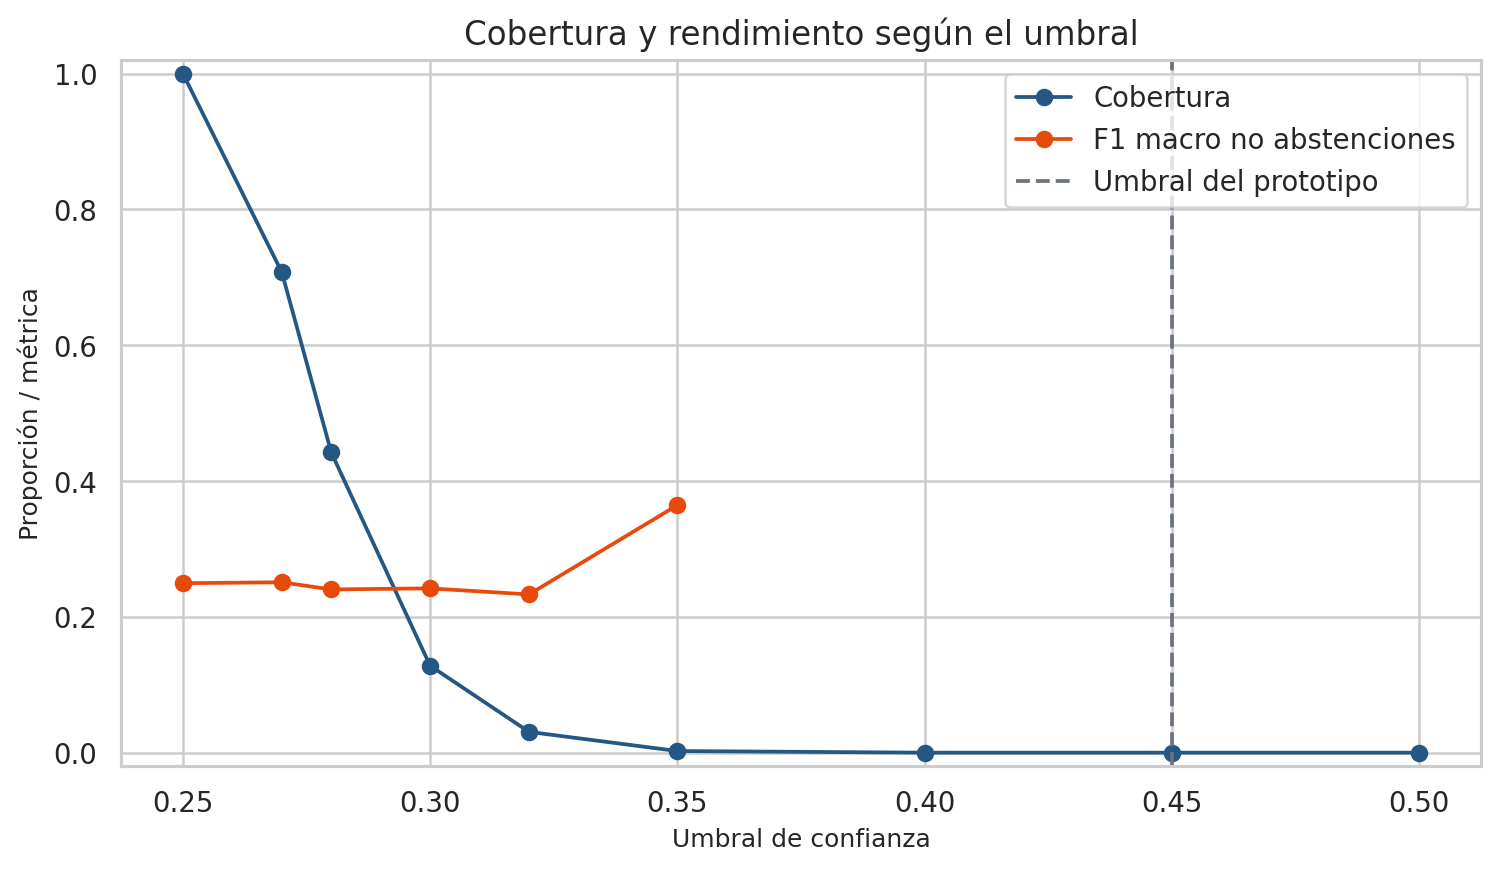

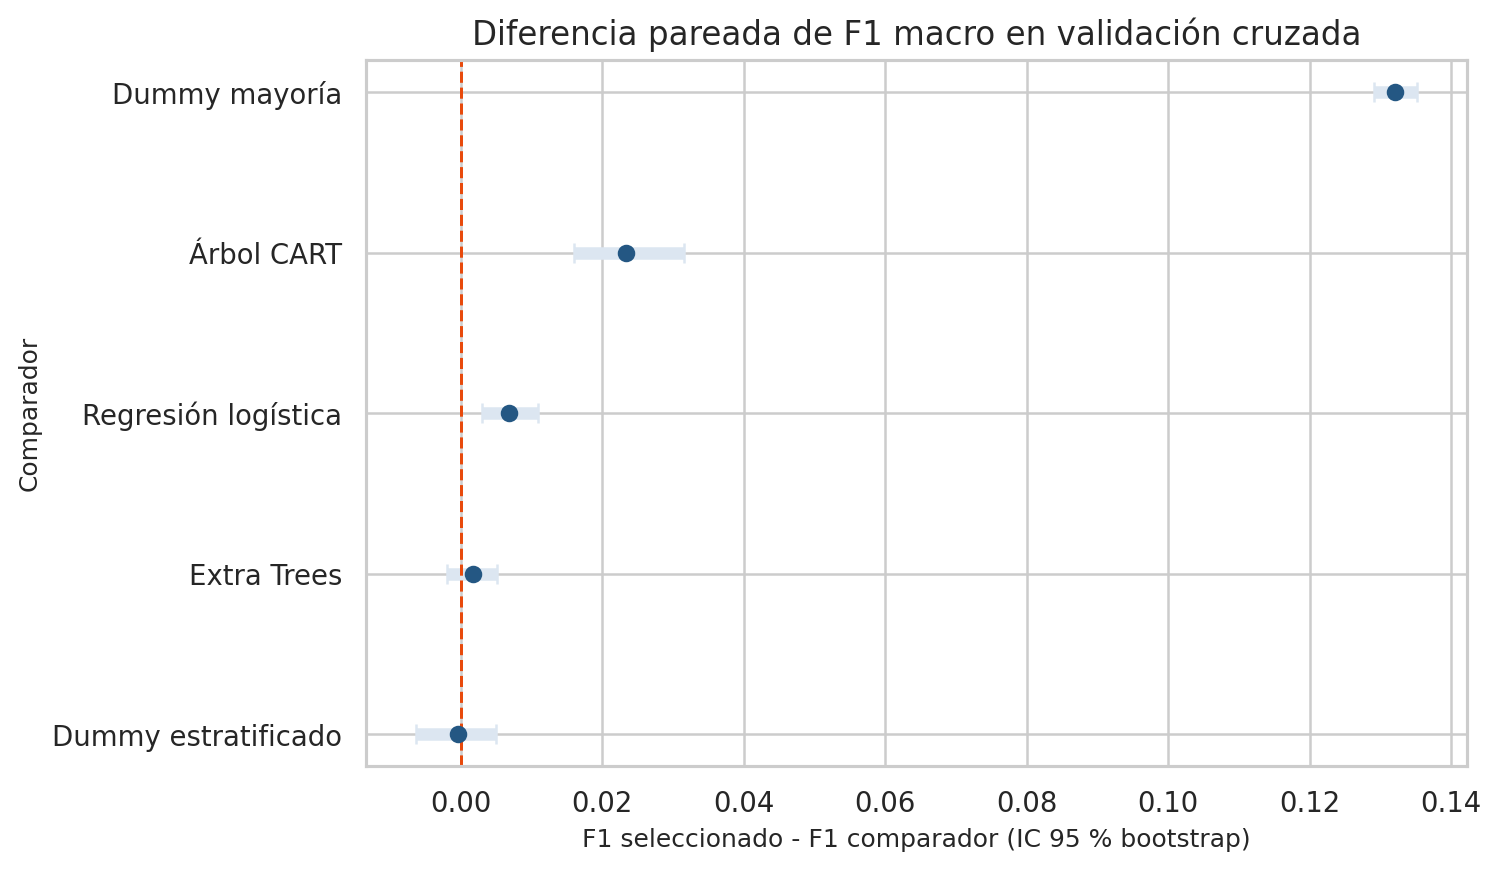

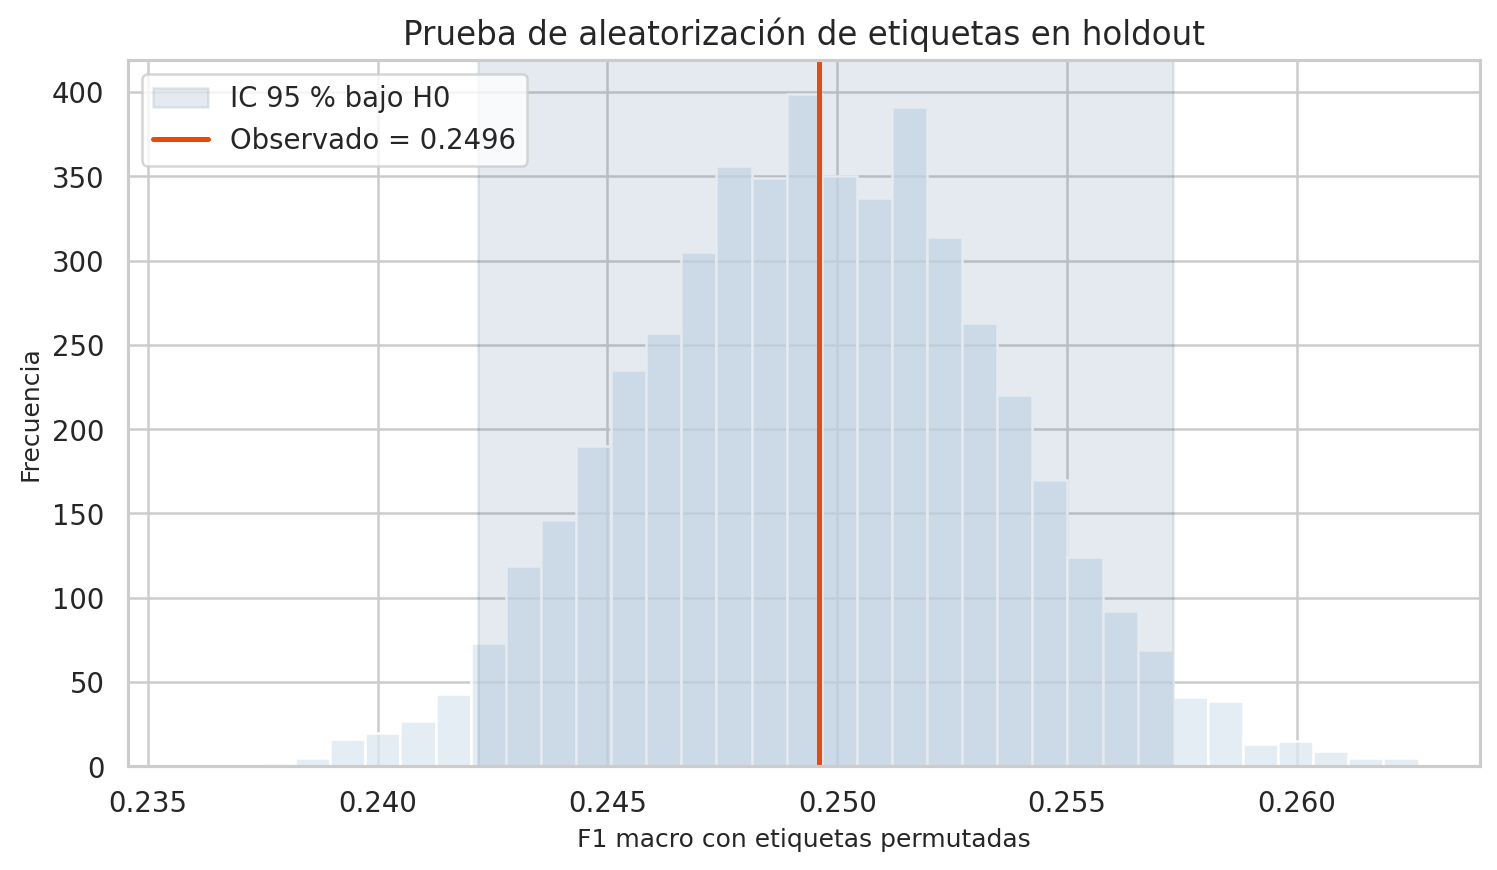

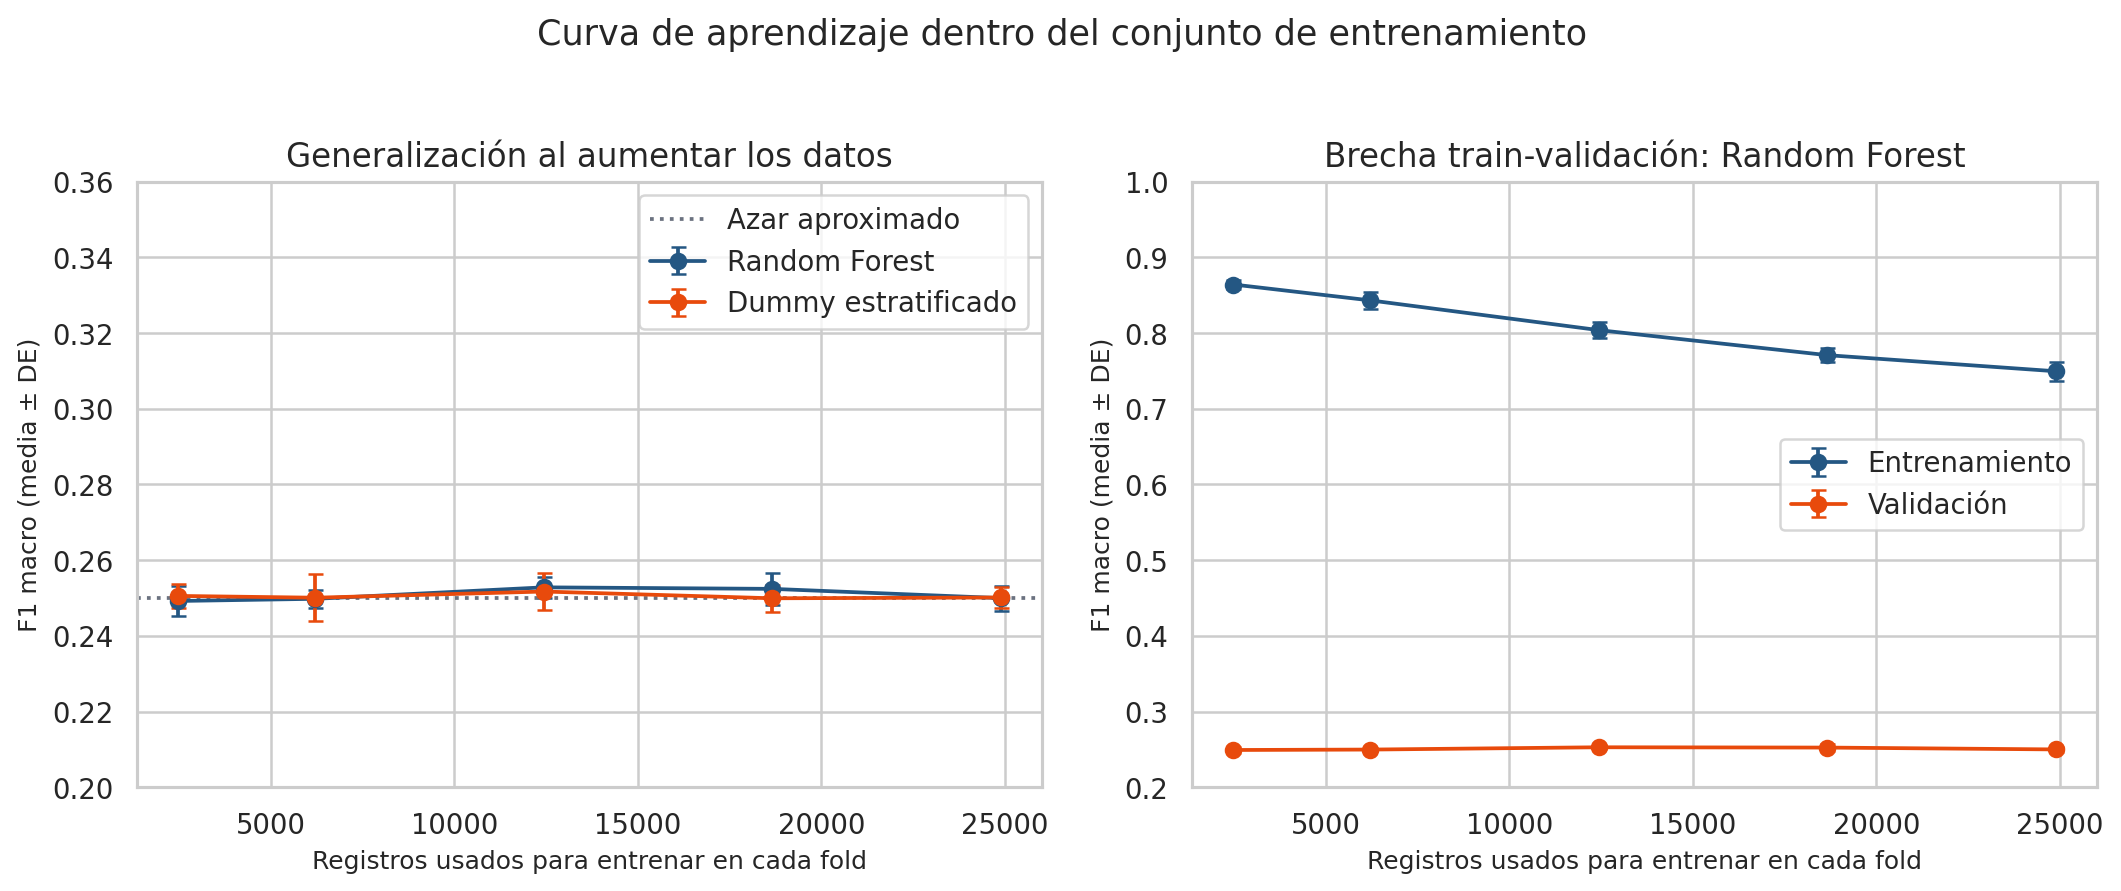

In [9]:
bootstrap = pd.read_csv(ROOT / "outputs/tables/25_ic_bootstrap_holdout.csv")
paired = pd.read_csv(ROOT / "outputs/tables/26_comparaciones_cv_pareadas.csv")
calibration = pd.read_csv(ROOT / "outputs/tables/27_calibracion_top_label.csv")
selective = pd.read_csv(ROOT / "outputs/tables/28_rendimiento_selectivo_umbral.csv")
randomization = pd.read_csv(ROOT / "outputs/tables/32_prueba_aleatorizacion_etiquetas.csv")
learning = pd.read_csv(ROOT / "outputs/tables/34_curva_aprendizaje.csv")
probabilistic_skill = pd.read_csv(ROOT / "outputs/tables/35_skill_probabilistico.csv")
display(bootstrap.round(4))
display(paired.round(4))
display(calibration.round(4))
display(selective.round(4))
display(randomization.round(4))
display(learning.round(4))
display(probabilistic_skill.round(4))
display(Image(filename=str(ROOT / "outputs/figures/13_calibracion_top_label.png"), width=650))
display(Image(filename=str(ROOT / "outputs/figures/14_rendimiento_selectivo.png"), width=760))
display(Image(filename=str(ROOT / "outputs/figures/16_comparaciones_cv_pareadas.png"), width=760))
display(Image(filename=str(ROOT / "outputs/figures/17_prueba_aleatorizacion.png"), width=760))
display(Image(filename=str(ROOT / "outputs/figures/18_curva_aprendizaje.png"), width=980))

Los intervalos bootstrap cuantifican incertidumbre del holdout. La comparación pareada utiliza los mismos folds para todos los modelos; si el intervalo de la diferencia incluye cero, no existe evidencia de una ventaja estable. La prueba de aleatorización contrasta directamente la concordancia observada con la independencia entre predicción y etiqueta. La curva de aprendizaje comprueba si más registros mejoran la generalización, y el skill probabilístico compara contra prevalencias aprendidas solo en train. La curva selectiva muestra que aumentar el umbral reduce cobertura y no crea validación clínica.

## 7. Interpretación y auditoría por subgrupos

,variable_transformada,importancia,metodo
0,bmi,0.206938,Importancia interna del ensemble
1,tumor_size_cm,0.193284,Importancia interna del ensemble
2,age,0.181481,Importancia interna del ensemble
3,tumor_stage_II,0.024093,Importancia interna del ensemble
4,sex_Male,0.024004,Importancia interna del ensemble
5,smoking_status_Never,0.023897,Importancia interna del ensemble
6,sex_Female,0.023702,Importancia interna del ensemble
7,smoking_status_Former,0.023449,Importancia interna del ensemble
8,tumor_stage_I,0.021635,Importancia interna del ensemble
9,tumor_stage_III,0.021254,Importancia interna del ensemble


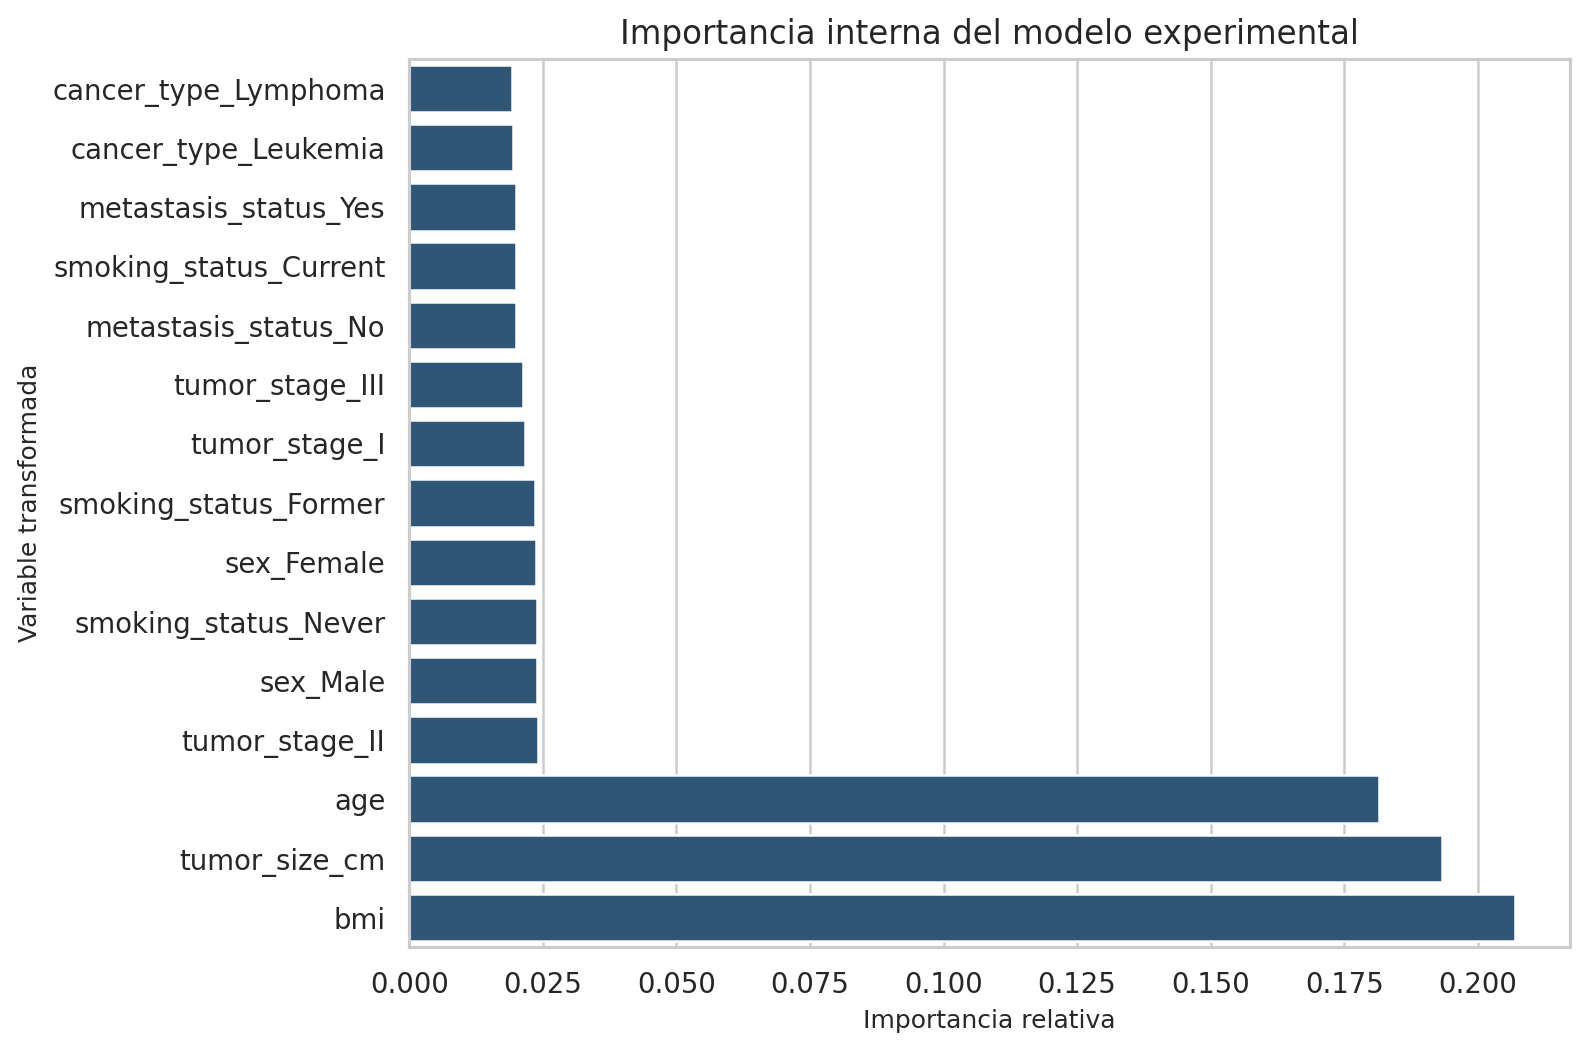

,variable,importancia_media,importancia_desviacion,limite_inferior_2sd,limite_superior_2sd,n_repeticiones,metodo
0,tumor_stage,0.0028,0.0022,-0.0017,0.0073,7,Disminución de F1 macro por permutación en hol...
1,bmi,0.0026,0.0024,-0.0021,0.0073,7,Disminución de F1 macro por permutación en hol...
2,genetic_mutation,0.0022,0.0035,-0.0047,0.0091,7,Disminución de F1 macro por permutación en hol...
3,smoking_status,0.0019,0.0031,-0.0042,0.0081,7,Disminución de F1 macro por permutación en hol...
4,metastasis_status,0.0016,0.0012,-0.0007,0.0040,7,Disminución de F1 macro por permutación en hol...
5,sex,0.0008,0.0019,-0.0029,0.0046,7,Disminución de F1 macro por permutación en hol...
6,tumor_size_cm,0.0002,0.0016,-0.0030,0.0033,7,Disminución de F1 macro por permutación en hol...
7,age,0.0001,0.0025,-0.0049,0.0050,7,Disminución de F1 macro por permutación en hol...
8,cancer_type,-0.0000,0.0019,-0.0037,0.0037,7,Disminución de F1 macro por permutación en hol...


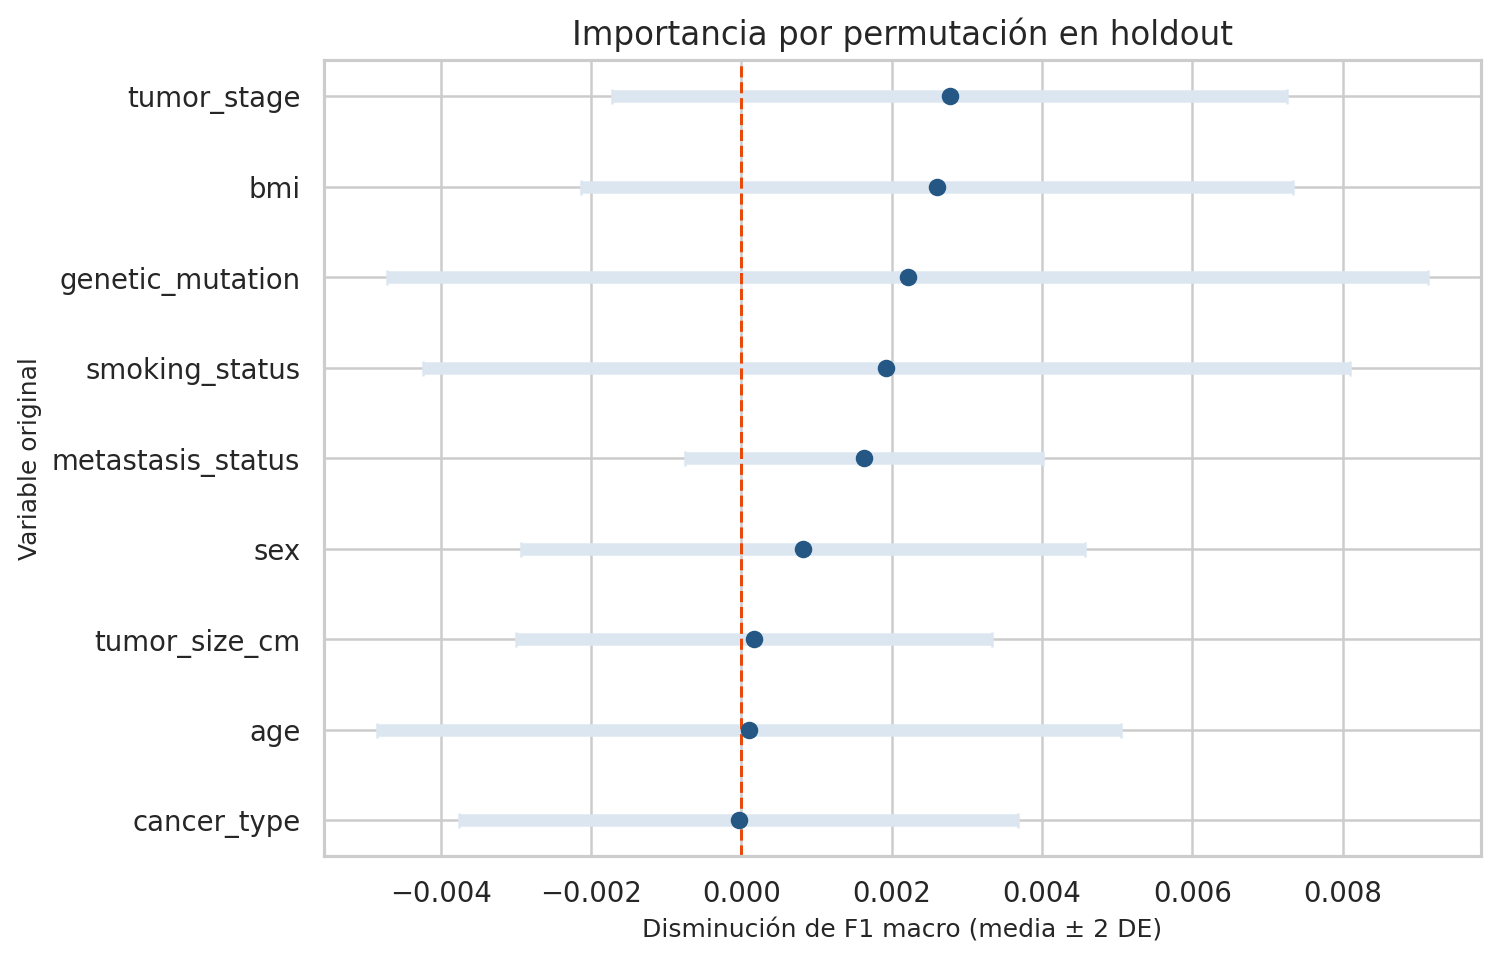

,atributo,grupo,n,accuracy,balanced_accuracy,f1_macro
0,sex,Female,6256,0.2490,0.2454,0.2448
1,sex,Male,6186,0.2598,0.2542,0.2539
2,age_group,50-64,3287,0.2619,0.2587,0.2579
3,age_group,65-74,2320,0.2440,0.2391,0.2384
4,age_group,<50,4501,0.2482,0.2436,0.2430
5,age_group,>=75,2334,0.2661,0.2632,0.2599


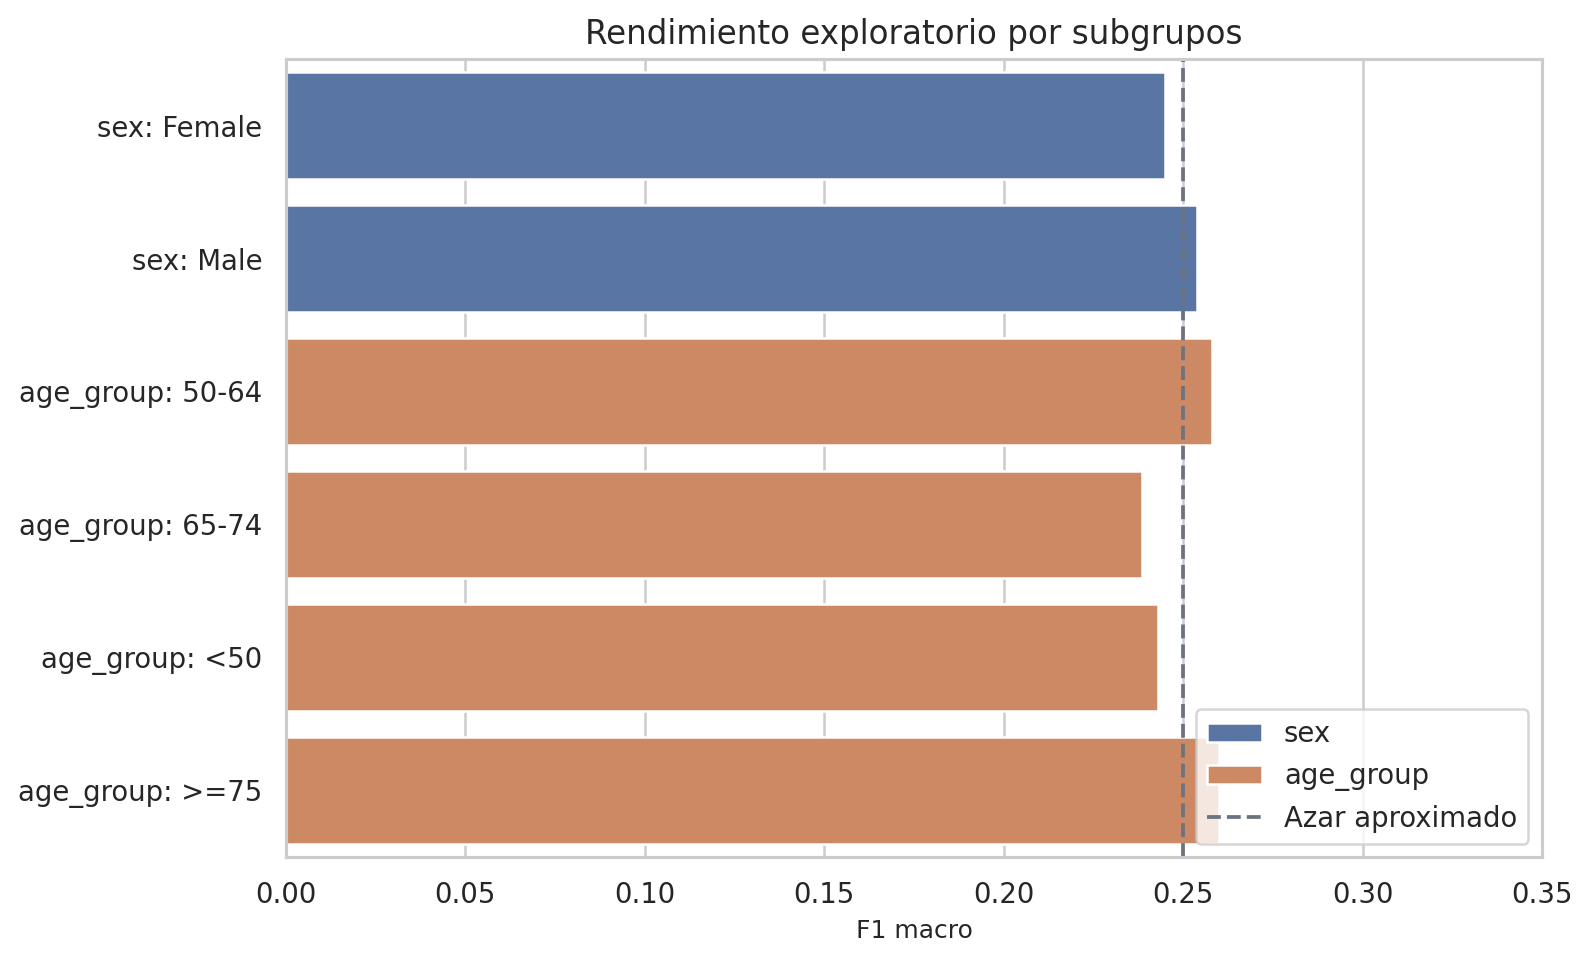

In [10]:
importance = pd.read_csv(ROOT / "outputs/tables/18_importancia_variables.csv")
permutation = pd.read_csv(ROOT / "outputs/tables/29_importancia_permutacion.csv")
subgroups = pd.read_csv(ROOT / "outputs/tables/19_rendimiento_subgrupos.csv")
display(importance.head(15))
display(Image(filename=str(ROOT / "outputs/figures/09_importancia_variables.png"), width=780))
display(permutation.round(4))
display(Image(filename=str(ROOT / "outputs/figures/15_importancia_permutacion.png"), width=760))
display(subgroups.round(4))
display(Image(filename=str(ROOT / "outputs/figures/10_rendimiento_subgrupos.png"), width=780))

La importancia interna se contrasta con permutación sobre el holdout. Si la pérdida de F1 no es estable o cruza cero, la variable no aporta señal robusta. Ninguna importancia demuestra causalidad y, con rendimiento global equivalente al azar, las explicaciones individuales tampoco deben considerarse clínicamente fiables.

## 8. Aprendizaje no supervisado

,k,inercia,silhouette,davies_bouldin
0,2,306138.6010,0.0978,2.9156
1,3,281313.3212,0.0895,2.5053
2,4,265148.9734,0.0849,2.3518
3,5,252712.0952,0.0832,2.3864
4,6,247986.7698,0.0740,2.5604


,cluster,n,proporcion,age_mean,bmi_mean,tumor_size_cm_mean,sex_mode,cancer_type_mode,tumor_stage_mode,metastasis_yes_rate,regimen_mode
0,0,23470,0.472,61.539,22.784,5.104,Male,Lung,II,0.305,FOLFOX
1,1,26295,0.528,53.080,30.277,5.836,Female,Leukemia,II,0.294,FOLFOX


,variable_1,variable_2,cramers_v_corregido,p_value_chi2,interpretacion
0,cluster,chemotherapy_regimen,0.0,0.590588,No valida utilidad clínica; solo mide asociaci...


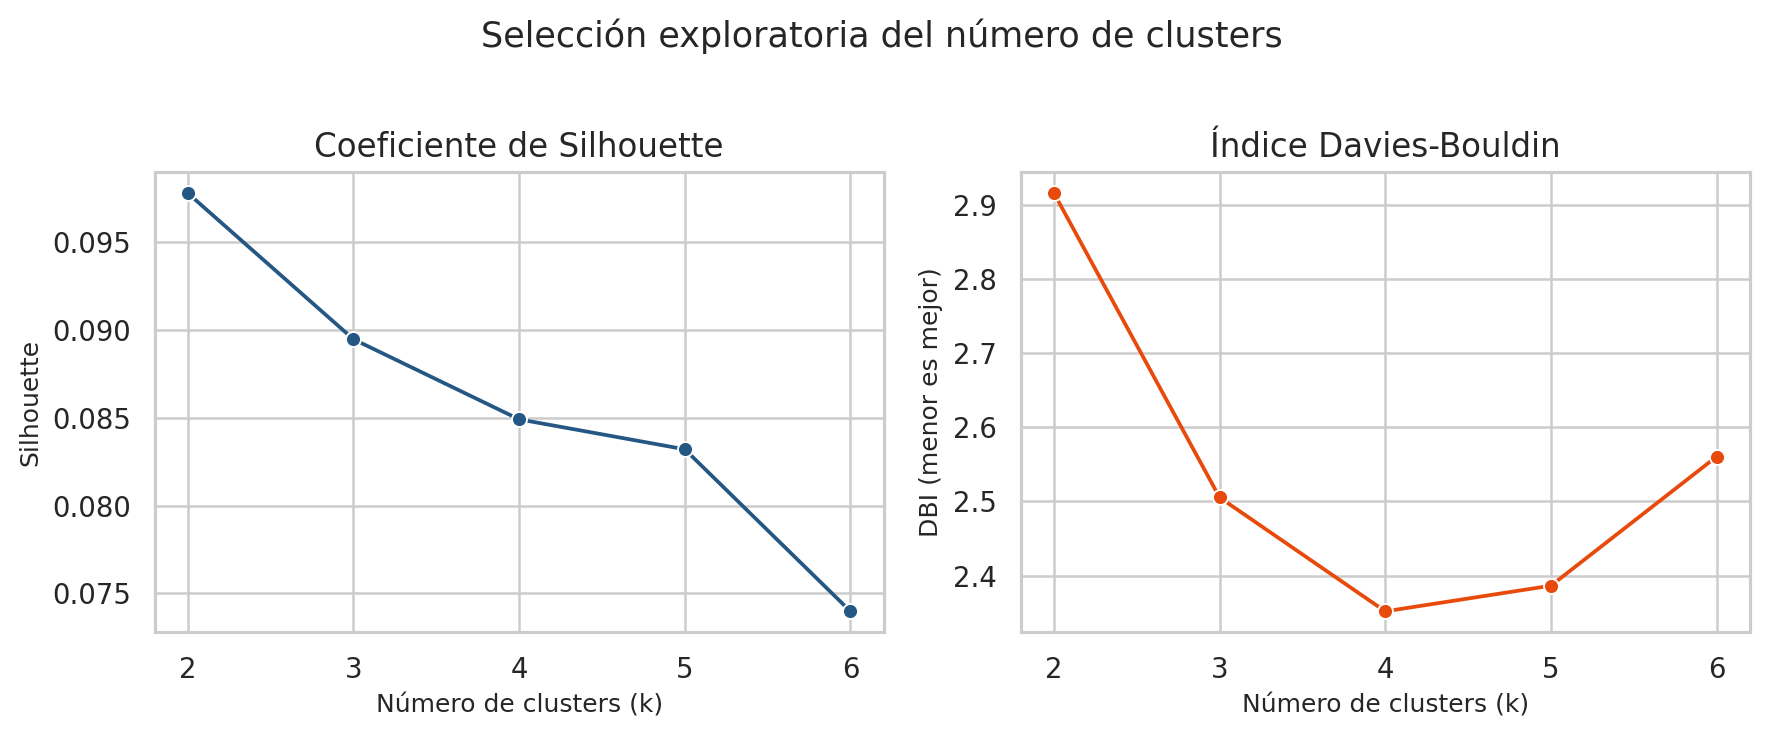

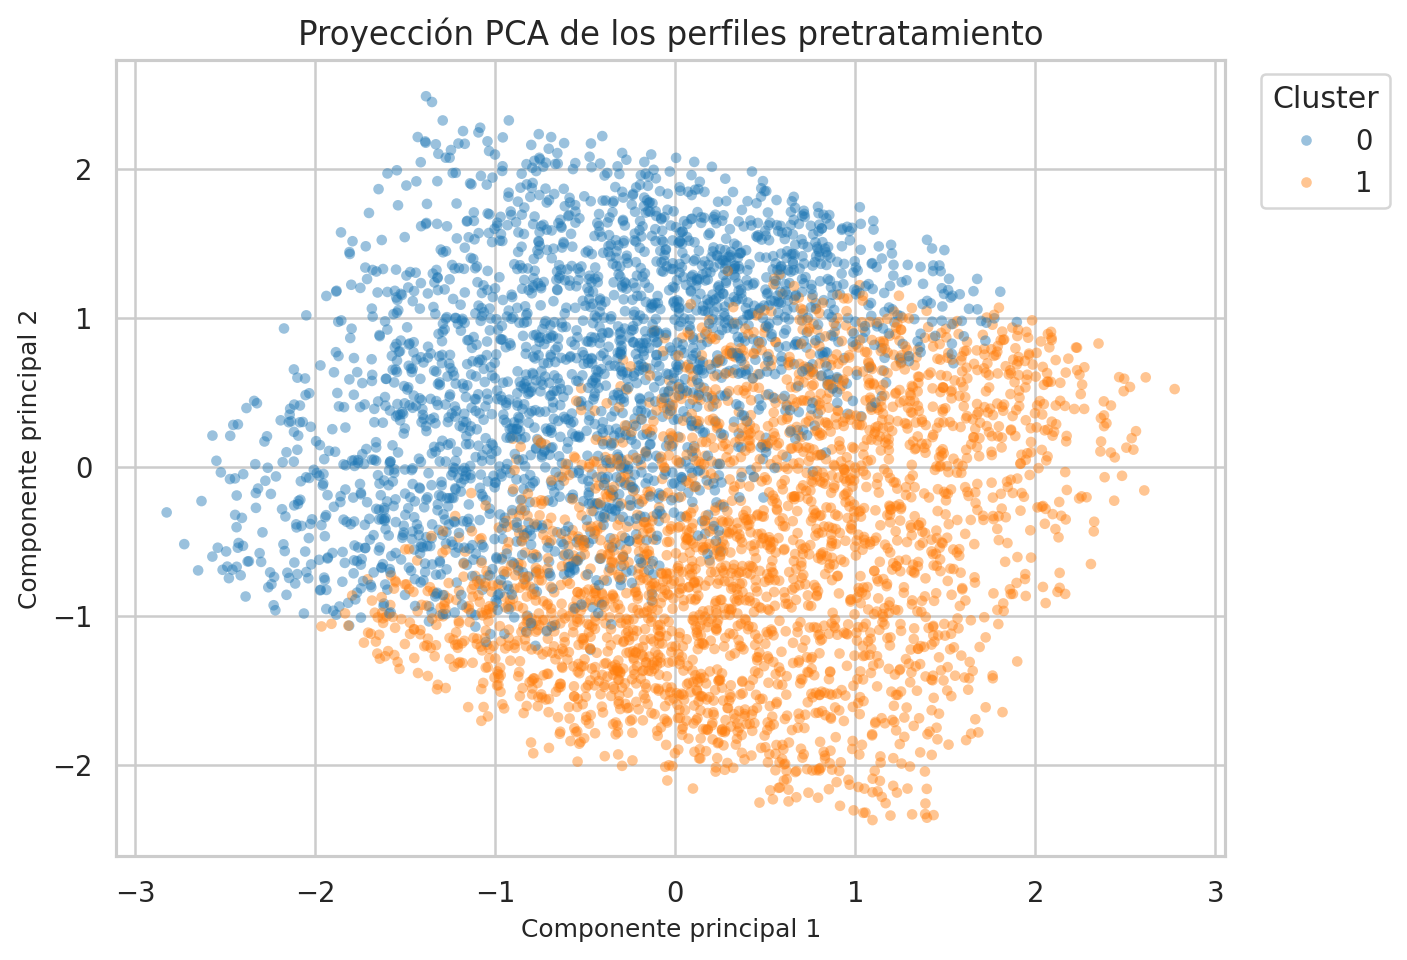

In [11]:
cluster_eval = pd.read_csv(ROOT / "outputs/tables/20_clustering_evaluacion_k.csv")
cluster_profiles = pd.read_csv(ROOT / "outputs/tables/21_clustering_perfiles.csv")
cluster_target = pd.read_csv(ROOT / "outputs/tables/22_clustering_asociacion_target.csv")
display(cluster_eval.round(4))
display(cluster_profiles.round(3))
display(cluster_target)
display(Image(filename=str(ROOT / "outputs/figures/11_clustering_metricas.png"), width=850))
display(Image(filename=str(ROOT / "outputs/figures/12_clustering_pca.png"), width=760))

El Silhouette bajo indica separación débil. Los clusters sirven para explorar perfiles, pero no deben convertirse en segmentos terapéuticos ni reglas de tratamiento.

## 9. Outcomes descriptivos

In [12]:
outcomes = pd.read_csv(ROOT / "outputs/tables/09_outcomes_descriptivos_por_regimen.csv")
display(outcomes.round(4))

,chemotherapy_regimen,n,response_favorable_rate,progressive_disease_rate,severe_toxicity_rate,survival_months_mean,survival_months_median
0,ABVD,13052,0.6040,0.0987,0.5151,62.8819,63.0
1,CHOP,10639,0.5973,0.0990,0.5217,62.4235,62.0
2,FOLFOX,15699,0.5965,0.0989,0.5153,62.6219,62.0
3,Gemcitabine,10375,0.6061,0.0995,0.5325,62.0835,62.0


Las tasas se presentan como descripción del dataset. No son estimaciones de eficacia o seguridad comparada: no existe aleatorización, ajuste de confusores, temporalidad ni protocolo de seguimiento acreditado.

## 10. Conclusión y decisión de avance

In [13]:
display(Markdown(f'''**Conclusión reproducible:** {summary["evidence_conclusion"]}

- Modelo experimental: {summary["selected_model"]}
- F1 macro CV: {summary["cv_f1_macro_mean"]:.4f}
- F1 macro Dummy estratificado: {summary["dummy_stratified_cv_f1_macro"]:.4f}
- F1 macro holdout: {summary["holdout_f1_macro"]:.4f}
- Balanced accuracy holdout: {summary["holdout_balanced_accuracy"]:.4f}
- Abstención en holdout: {summary["abstention_rate_holdout"]:.1%}
- p de aleatorización: {summary["label_randomization_p_value"]:.4f}
- Brier skill vs prevalencia: {summary["brier_skill_vs_prevalence"]:.4f}
- F1 final de curva de aprendizaje: {summary["learning_curve_final_validation_f1"]:.4f}
- Mejor Silhouette: {summary["clustering_silhouette"]:.4f}
'''))

**Conclusión reproducible:** No se demuestra señal predictiva útil: F1 macro y balanced accuracy son equivalentes al azar.

- Modelo experimental: Random Forest
- F1 macro CV: 0.2521
- F1 macro Dummy estratificado: 0.2525
- F1 macro holdout: 0.2496
- Balanced accuracy holdout: 0.2499
- Abstención en holdout: 100.0%
- p de aleatorización: 0.4991
- Brier skill vs prevalencia: -0.0118
- F1 final de curva de aprendizaje: 0.2500
- Mejor Silhouette: 0.0978


### Decisión

El resultado establece un **NO-GO clínico** y conserva valor como prueba de concepto de ingeniería, auditoría de IA y control de abstención. Para avanzar se necesita una cohorte con procedencia clínica, temporalidad, variables relevantes, validación externa y revisión por especialistas.

### Material docente aplicado

- Tema 1: KDD y CRISP-DM.
- Tema 2: EDA, calidad, outliers y prevención de leakage.
- Tema 3: modelos supervisados y métricas.
- Tema 4: clustering, Silhouette y Davies-Bouldin.
- Tema 5: jerarquía visual y data storytelling.
- Tema 6: dashboard como interfaz de decisión, gobernanza y validación.
- Guía de métricas: balanced accuracy, F1, log-loss y métricas de clustering.